In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from scripts import model_evaluation as model_eval


In [252]:
X_train = pd.read_parquet('X_train_cleaned.parquet')
X_test = pd.read_parquet('X_test_cleaned.parquet')

y_train = pd.read_parquet('y_train.parquet')
y_test = pd.read_parquet('y_test.parquet')

In [253]:
X_train.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [254]:
cat_yes_no_cols = ['PhoneService', 'OnlineSecurity', 'StreamingTV', 'StreamingMovies']
cat_contract_cols = ['Contract']
cat_internetservice_cols = ['InternetService']

cat_yes_no_val_order = [['No', 'Yes']]*len(cat_yes_no_cols)
cat_contract_val_order = [['Month-to-month', 'One year', 'Two year']]*len(cat_contract_cols)
cat_internetservice_val_order = [['DSL', 'Fiber optic', 'No']]*len(cat_internetservice_cols)

drop_cols = ['gender', 'Partner', 'PaymentMethod',  'Dependents', 'TotalCharges', 'DeviceProtection', 'OnlineBackup', 'PaperlessBilling', 'TechSupport', 'MultipleLines', ]
    

In [255]:
yesno_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('ordinal_yesno_encode', OrdinalEncoder(categories=cat_yes_no_val_order))
])

internetservice_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot_internetservice_encode', OneHotEncoder(categories=cat_internetservice_val_order, drop='first', sparse_output=False, handle_unknown='ignore')),
])

contract_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('ordinal_contract_encode', OrdinalEncoder(categories=cat_contract_val_order))
])

In [256]:
preprocessor = ColumnTransformer([
    ('ohe_yesno_encoder', yesno_encoder_pipeline, cat_yes_no_cols),
    ('ohe_internetservice_encoder', internetservice_encoder_pipeline, cat_internetservice_cols),
    ('ordinal_contract_encoder', contract_encoder_pipeline, cat_contract_cols),
], remainder='passthrough')

In [257]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.cols)

In [258]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.tenure_max_ = None

    def fit(self, X, y=None):
        self.tenure_max_ = X['tenure'].max()
        self.monthly_charge_mean_ = X['MonthlyCharges'].mean()
        return self

    def transform(self, X):
        X = X.copy()

        engagementscore = (
            (X['StreamingTV'] == 'Yes').astype(int) +
            (X['StreamingMovies'] == 'Yes').astype(int) +
            (X['OnlineBackup'] == 'Yes').astype(int) +
            (X['DeviceProtection'] == 'Yes').astype(int) +
            (X['TechSupport'] == 'Yes').astype(int) +
            (X['OnlineSecurity'] == 'Yes').astype(int)
        )

        X["riskypaymentsegment"] = (
            (X["PaymentMethod"] == "Electronic check") &
            (X["PaperlessBilling"] == "Yes")
        ).astype(int)

        X['service_density'] = engagementscore / (X['tenure'] + 1)

        X['avg_monthly_spend'] = X['TotalCharges'] / (X['tenure'] + 1)
        X['cost_volatility'] = X['MonthlyCharges'] - X['avg_monthly_spend']

        X['high_cost_short_tenure'] = X['MonthlyCharges'] * (X['tenure'] < 12)

        X['no_support_high_risk'] = (
            (X['TechSupport'] == 'No') &
            (X['OnlineSecurity'] == 'No')
        ).astype(int)

        X['MaturityScore'] = X['tenure'] * engagementscore

        service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
        service_adoption_rate = X[service_cols].apply(
            lambda row: (row == 'Yes').sum() / len(service_cols), axis=1
        )

        X['charge_per_service'] = X['MonthlyCharges'] / (service_adoption_rate * 6 + 1)


        X['loyalty_index'] = (
            X['tenure'] *
            X['Contract'].map({'Month-to-month': 0.5, 'One year': 1.5, 'Two year': 3.0}) *
            (1 + service_adoption_rate)
        )

        X['engaged_loyalty'] = engagementscore * X['Contract'].map({
            'Month-to-month': 0.5, 'One year': 1.5, 'Two year': 3.0
        })

        X['longterm_customers'] = (
            (X['Contract'] != 'Month-to-month').astype(int) +
            (X['Dependents'] == 'Yes').astype(int) +
            (X['tenure'] >= 5).astype(int) +
            (X['tenure'] >= 24).astype(int) +
            (X['PaperlessBilling'] == 'No').astype(int)
        )

        X["fiber_noprotection"] = (
            (X["InternetService"] == "Fiber optic") &
            (X["TechSupport"] == "No") &
            (X["OnlineSecurity"] == "No")
        ).astype(int)
    
        return X

In [259]:
model_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('drop_cols', DropColumns(cols=drop_cols)),
    ('preprocessing', preprocessor),
    ('model', xgb.XGBClassifier(objective="binary:logistic"))
])

In [260]:
def objective(trial):
    params = {
        "model__n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "model__max_depth":        trial.suggest_int("max_depth", 3, 10),
        "model__learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "model__subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "model__min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "model__gamma":            trial.suggest_float("gamma", 0.0, 0.5),
        "model__reg_alpha":        trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "model__reg_lambda":       trial.suggest_float("reg_lambda", 0.1, 5.0),
        "model__scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 3.0),
    }

    pipeline = model_pipeline.set_params(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    return scores.mean()


In [261]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=80, show_progress_bar=True)

[I 2026-05-06 19:53:01,792] A new study created in memory with name: no-name-2393c535-e416-41ca-ab97-e8aefb512fbb
Best trial: 0. Best value: 0.71574:   1%|▏         | 1/80 [00:02<02:43,  2.07s/it]

[I 2026-05-06 19:53:03,855] Trial 0 finished with value: 0.7157399000144082 and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.07441632389160634, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'reg_alpha': 2.1766241123453676, 'reg_lambda': 3.0454635575417233, 'scale_pos_weight': 2.2701814444901136}. Best is trial 0 with value: 0.7157399000144082.


Best trial: 0. Best value: 0.71574:   2%|▎         | 2/80 [00:03<01:51,  1.43s/it]

[I 2026-05-06 19:53:04,836] Trial 1 finished with value: 0.7043166469203362 and parameters: {'n_estimators': 216, 'max_depth': 10, 'learning_rate': 0.10779361932748845, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'min_child_weight': 2, 'gamma': 0.15212112147976886, 'reg_alpha': 0.2607965659809584, 'reg_lambda': 2.2165305913463675, 'scale_pos_weight': 1.2280728504951048}. Best is trial 0 with value: 0.7157399000144082.


Best trial: 0. Best value: 0.71574:   4%|▍         | 3/80 [00:04<01:40,  1.31s/it]

[I 2026-05-06 19:53:06,002] Trial 2 finished with value: 0.6794519278752686 and parameters: {'n_estimators': 690, 'max_depth': 4, 'learning_rate': 0.014689372953975089, 'subsample': 0.7465447373174767, 'colsample_bytree': 0.7824279936868144, 'min_child_weight': 8, 'gamma': 0.09983689107917987, 'reg_alpha': 0.24428866967349966, 'reg_lambda': 3.0028313874240085, 'scale_pos_weight': 0.6161260317999944}. Best is trial 0 with value: 0.7157399000144082.


Best trial: 3. Best value: 0.745706:   5%|▌         | 4/80 [00:05<01:51,  1.46s/it]

[I 2026-05-06 19:53:07,701] Trial 3 finished with value: 0.7457055945715736 and parameters: {'n_estimators': 686, 'max_depth': 4, 'learning_rate': 0.006356039080497238, 'subsample': 0.9795542149013333, 'colsample_bytree': 0.9862528132298237, 'min_child_weight': 9, 'gamma': 0.15230688458668534, 'reg_alpha': 0.01834907204905546, 'reg_lambda': 3.452741829909569, 'scale_pos_weight': 1.6003812343490034}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:   6%|▋         | 5/80 [00:07<01:57,  1.56s/it]

[I 2026-05-06 19:53:09,444] Trial 4 finished with value: 0.6886011141062317 and parameters: {'n_estimators': 297, 'max_depth': 6, 'learning_rate': 0.005676262589955586, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.7035119926400067, 'min_child_weight': 7, 'gamma': 0.15585553804470548, 'reg_alpha': 0.25330746540014476, 'reg_lambda': 2.7788803687820707, 'scale_pos_weight': 0.9621361388138177}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:   8%|▊         | 6/80 [00:09<02:07,  1.72s/it]

[I 2026-05-06 19:53:11,472] Trial 5 finished with value: 0.693609945939508 and parameters: {'n_estimators': 976, 'max_depth': 9, 'learning_rate': 0.15999399049657148, 'subsample': 0.9579309401710595, 'colsample_bytree': 0.8391599915244341, 'min_child_weight': 10, 'gamma': 0.04424625102595975, 'reg_alpha': 0.03380273704712441, 'reg_lambda': 0.32161371566163655, 'scale_pos_weight': 1.313325826908161}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:   9%|▉         | 7/80 [00:11<02:18,  1.90s/it]

[I 2026-05-06 19:53:13,735] Trial 6 finished with value: 0.715966952412858 and parameters: {'n_estimators': 511, 'max_depth': 5, 'learning_rate': 0.10633034207853799, 'subsample': 0.7427013306774357, 'colsample_bytree': 0.7123738038749523, 'min_child_weight': 6, 'gamma': 0.07046211248738132, 'reg_alpha': 1.4625327121207685, 'reg_lambda': 0.46529815403087704, 'scale_pos_weight': 2.9672173415012932}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  10%|█         | 8/80 [00:14<02:34,  2.15s/it]

[I 2026-05-06 19:53:16,426] Trial 7 finished with value: 0.7011130682263212 and parameters: {'n_estimators': 818, 'max_depth': 4, 'learning_rate': 0.005102896587491044, 'subsample': 0.9261845713819337, 'colsample_bytree': 0.8827429375390468, 'min_child_weight': 8, 'gamma': 0.38563517334297287, 'reg_alpha': 0.015843250684388695, 'reg_lambda': 1.856482069866936, 'scale_pos_weight': 0.7896726488128243}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  11%|█▏        | 9/80 [00:18<03:21,  2.84s/it]

[I 2026-05-06 19:53:20,771] Trial 8 finished with value: 0.7340111371979199 and parameters: {'n_estimators': 891, 'max_depth': 7, 'learning_rate': 0.01694683071232564, 'subsample': 0.6254233401144095, 'colsample_bytree': 0.7243929286862649, 'min_child_weight': 4, 'gamma': 0.36480308916903204, 'reg_alpha': 0.5257127272786867, 'reg_lambda': 4.447342438624, 'scale_pos_weight': 1.6805373129048733}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  12%|█▎        | 10/80 [00:21<03:03,  2.62s/it]

[I 2026-05-06 19:53:22,899] Trial 9 finished with value: 0.6959750059389557 and parameters: {'n_estimators': 295, 'max_depth': 8, 'learning_rate': 0.08275481892245508, 'subsample': 0.8245108790277985, 'colsample_bytree': 0.9083868719818244, 'min_child_weight': 5, 'gamma': 0.26136641469099703, 'reg_alpha': 0.14253462720121496, 'reg_lambda': 0.22455372104606644, 'scale_pos_weight': 0.7697285674832611}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  14%|█▍        | 11/80 [00:23<02:49,  2.46s/it]

[I 2026-05-06 19:53:24,986] Trial 10 finished with value: 0.7380613645483132 and parameters: {'n_estimators': 669, 'max_depth': 3, 'learning_rate': 0.03379843720918387, 'subsample': 0.8838191386946925, 'colsample_bytree': 0.9935584941681304, 'min_child_weight': 10, 'gamma': 0.4798853729727099, 'reg_alpha': 0.0556785195763802, 'reg_lambda': 4.758013132390248, 'scale_pos_weight': 2.109281841559559}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  15%|█▌        | 12/80 [00:25<02:41,  2.37s/it]

[I 2026-05-06 19:53:27,155] Trial 11 finished with value: 0.7373569057377407 and parameters: {'n_estimators': 704, 'max_depth': 3, 'learning_rate': 0.03374803000602743, 'subsample': 0.8842558606631495, 'colsample_bytree': 0.997602323637893, 'min_child_weight': 10, 'gamma': 0.49547516045555867, 'reg_alpha': 0.03872400683539922, 'reg_lambda': 4.804163203755742, 'scale_pos_weight': 2.1629507599335303}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  16%|█▋        | 13/80 [00:27<02:30,  2.25s/it]

[I 2026-05-06 19:53:29,142] Trial 12 finished with value: 0.7385400359173164 and parameters: {'n_estimators': 592, 'max_depth': 3, 'learning_rate': 0.028174997309276275, 'subsample': 0.8890025788276394, 'colsample_bytree': 0.9965029314030618, 'min_child_weight': 10, 'gamma': 0.2585006738258346, 'reg_alpha': 0.011953740691317744, 'reg_lambda': 3.900080795944814, 'scale_pos_weight': 2.0366465722396505}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  18%|█▊        | 14/80 [00:29<02:33,  2.33s/it]

[I 2026-05-06 19:53:31,631] Trial 13 finished with value: 0.7413911778828228 and parameters: {'n_estimators': 526, 'max_depth': 5, 'learning_rate': 0.010532731290901412, 'subsample': 0.9991293294808036, 'colsample_bytree': 0.9375920406844779, 'min_child_weight': 8, 'gamma': 0.2436755708358054, 'reg_alpha': 0.010457522665742326, 'reg_lambda': 3.930879212093915, 'scale_pos_weight': 1.761192735043553}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 3. Best value: 0.745706:  19%|█▉        | 15/80 [00:32<02:36,  2.41s/it]

[I 2026-05-06 19:53:34,260] Trial 14 finished with value: 0.743488075186687 and parameters: {'n_estimators': 449, 'max_depth': 6, 'learning_rate': 0.009635864086906818, 'subsample': 0.9979204709678574, 'colsample_bytree': 0.9281889012746767, 'min_child_weight': 8, 'gamma': 0.18983067423136177, 'reg_alpha': 0.010153868512891325, 'reg_lambda': 3.583992979050558, 'scale_pos_weight': 1.62137014222519}. Best is trial 3 with value: 0.7457055945715736.


Best trial: 15. Best value: 0.747234:  20%|██        | 16/80 [00:34<02:34,  2.42s/it]

[I 2026-05-06 19:53:36,677] Trial 15 finished with value: 0.7472335072177445 and parameters: {'n_estimators': 413, 'max_depth': 6, 'learning_rate': 0.008429395931873399, 'subsample': 0.9909777802763841, 'colsample_bytree': 0.6018960478612357, 'min_child_weight': 7, 'gamma': 0.1691144214334228, 'reg_alpha': 0.07489485937937916, 'reg_lambda': 3.6352029576906935, 'scale_pos_weight': 1.5188122292796458}. Best is trial 15 with value: 0.7472335072177445.


Best trial: 15. Best value: 0.747234:  21%|██▏       | 17/80 [00:37<02:41,  2.57s/it]

[I 2026-05-06 19:53:39,597] Trial 16 finished with value: 0.7383066930492902 and parameters: {'n_estimators': 373, 'max_depth': 7, 'learning_rate': 0.007470601740777077, 'subsample': 0.9263057324437728, 'colsample_bytree': 0.6019896562758476, 'min_child_weight': 4, 'gamma': 0.19770116555612005, 'reg_alpha': 0.0677971742335816, 'reg_lambda': 1.5742815871796652, 'scale_pos_weight': 2.5349842639445788}. Best is trial 15 with value: 0.7472335072177445.


Best trial: 15. Best value: 0.747234:  22%|██▎       | 18/80 [00:39<02:30,  2.42s/it]

[I 2026-05-06 19:53:41,683] Trial 17 finished with value: 0.7462305603864978 and parameters: {'n_estimators': 401, 'max_depth': 5, 'learning_rate': 0.014770368950716416, 'subsample': 0.7759633080780796, 'colsample_bytree': 0.7793629380168536, 'min_child_weight': 6, 'gamma': 0.11864835609819174, 'reg_alpha': 0.11461033349037474, 'reg_lambda': 3.558636163632573, 'scale_pos_weight': 1.329785042833565}. Best is trial 15 with value: 0.7472335072177445.


Best trial: 15. Best value: 0.747234:  24%|██▍       | 19/80 [00:41<02:21,  2.32s/it]

[I 2026-05-06 19:53:43,761] Trial 18 finished with value: 0.7401559069468964 and parameters: {'n_estimators': 403, 'max_depth': 5, 'learning_rate': 0.020153225530288484, 'subsample': 0.7603864950608998, 'colsample_bytree': 0.7727431143998708, 'min_child_weight': 6, 'gamma': 0.10578620297608071, 'reg_alpha': 0.10422970368364158, 'reg_lambda': 4.260950758607471, 'scale_pos_weight': 1.2109004671305588}. Best is trial 15 with value: 0.7472335072177445.


Best trial: 15. Best value: 0.747234:  25%|██▌       | 20/80 [00:44<02:27,  2.46s/it]

[I 2026-05-06 19:53:46,548] Trial 19 finished with value: 0.743062559143346 and parameters: {'n_estimators': 323, 'max_depth': 8, 'learning_rate': 0.010287800790756994, 'subsample': 0.7934613967542267, 'colsample_bytree': 0.6060084846502748, 'min_child_weight': 4, 'gamma': 0.3084333598049012, 'reg_alpha': 0.5941215060513348, 'reg_lambda': 1.3168459944227622, 'scale_pos_weight': 1.3891281741294836}. Best is trial 15 with value: 0.7472335072177445.


Best trial: 15. Best value: 0.747234:  26%|██▋       | 21/80 [00:46<02:13,  2.26s/it]

[I 2026-05-06 19:53:48,335] Trial 20 finished with value: 0.7230276398762168 and parameters: {'n_estimators': 230, 'max_depth': 6, 'learning_rate': 0.05339535559524547, 'subsample': 0.6855721815900874, 'colsample_bytree': 0.8293836422511812, 'min_child_weight': 5, 'gamma': 0.008679201752884419, 'reg_alpha': 0.654675591918076, 'reg_lambda': 2.289191274140598, 'scale_pos_weight': 1.0298614384025782}. Best is trial 15 with value: 0.7472335072177445.


Best trial: 21. Best value: 0.747914:  28%|██▊       | 22/80 [00:48<02:12,  2.28s/it]

[I 2026-05-06 19:53:50,662] Trial 21 finished with value: 0.7479141984545674 and parameters: {'n_estimators': 611, 'max_depth': 4, 'learning_rate': 0.007530687201576071, 'subsample': 0.8431327852364797, 'colsample_bytree': 0.755374024452766, 'min_child_weight': 7, 'gamma': 0.15073312973931433, 'reg_alpha': 0.023356947707515296, 'reg_lambda': 3.35181217755384, 'scale_pos_weight': 1.5201334762664613}. Best is trial 21 with value: 0.7479141984545674.


Best trial: 21. Best value: 0.747914:  29%|██▉       | 23/80 [00:51<02:14,  2.36s/it]

[I 2026-05-06 19:53:53,196] Trial 22 finished with value: 0.7422717977165026 and parameters: {'n_estimators': 598, 'max_depth': 5, 'learning_rate': 0.012850459882633784, 'subsample': 0.8380160878547869, 'colsample_bytree': 0.7529012845065695, 'min_child_weight': 7, 'gamma': 0.10646478371824669, 'reg_alpha': 0.02735524498686443, 'reg_lambda': 3.358741240936773, 'scale_pos_weight': 1.9117860225567709}. Best is trial 21 with value: 0.7479141984545674.


Best trial: 23. Best value: 0.748847:  30%|███       | 24/80 [00:53<02:06,  2.26s/it]

[I 2026-05-06 19:53:55,236] Trial 23 finished with value: 0.7488474526840343 and parameters: {'n_estimators': 443, 'max_depth': 4, 'learning_rate': 0.008154118624203923, 'subsample': 0.7079207538165652, 'colsample_bytree': 0.8108198786132831, 'min_child_weight': 7, 'gamma': 0.21079270075482515, 'reg_alpha': 0.10354886524778062, 'reg_lambda': 4.0189141856124735, 'scale_pos_weight': 1.4822594309107455}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  31%|███▏      | 25/80 [00:55<02:00,  2.20s/it]

[I 2026-05-06 19:53:57,289] Trial 24 finished with value: 0.7485556670983307 and parameters: {'n_estimators': 453, 'max_depth': 4, 'learning_rate': 0.008016175851396289, 'subsample': 0.708013781705426, 'colsample_bytree': 0.8254812419198323, 'min_child_weight': 7, 'gamma': 0.21040097520039006, 'reg_alpha': 0.08352765460346209, 'reg_lambda': 4.042266807286202, 'scale_pos_weight': 1.4993736273626037}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  32%|███▎      | 26/80 [00:57<02:01,  2.25s/it]

[I 2026-05-06 19:53:59,648] Trial 25 finished with value: 0.7416836761581583 and parameters: {'n_estimators': 580, 'max_depth': 4, 'learning_rate': 0.025204672302661827, 'subsample': 0.7028724673646195, 'colsample_bytree': 0.8436336897071393, 'min_child_weight': 7, 'gamma': 0.304185936321064, 'reg_alpha': 0.026289931884500326, 'reg_lambda': 4.253470824373789, 'scale_pos_weight': 1.8626546123859764}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  34%|███▍      | 27/80 [00:59<01:53,  2.15s/it]

[I 2026-05-06 19:54:01,577] Trial 26 finished with value: 0.7285168722429685 and parameters: {'n_estimators': 476, 'max_depth': 3, 'learning_rate': 0.00705167116264018, 'subsample': 0.6198037408596571, 'colsample_bytree': 0.8177647838541863, 'min_child_weight': 9, 'gamma': 0.22855456702063914, 'reg_alpha': 0.0518159878134604, 'reg_lambda': 4.961875376046126, 'scale_pos_weight': 1.0780067860661864}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  35%|███▌      | 28/80 [01:02<02:00,  2.31s/it]

[I 2026-05-06 19:54:04,250] Trial 27 finished with value: 0.7473597679496395 and parameters: {'n_estimators': 790, 'max_depth': 4, 'learning_rate': 0.011791681905860102, 'subsample': 0.71904297226848, 'colsample_bytree': 0.749208256915007, 'min_child_weight': 5, 'gamma': 0.299349930562578, 'reg_alpha': 0.15674691584123893, 'reg_lambda': 4.404142813783064, 'scale_pos_weight': 1.4794049666543492}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  36%|███▋      | 29/80 [01:04<01:56,  2.29s/it]

[I 2026-05-06 19:54:06,507] Trial 28 finished with value: 0.7349404098957645 and parameters: {'n_estimators': 549, 'max_depth': 4, 'learning_rate': 0.00765540765609507, 'subsample': 0.6597891899758822, 'colsample_bytree': 0.8754006721464517, 'min_child_weight': 9, 'gamma': 0.200573031414716, 'reg_alpha': 0.08929543594746721, 'reg_lambda': 3.980591140374619, 'scale_pos_weight': 2.460133522517899}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  38%|███▊      | 30/80 [01:06<01:53,  2.27s/it]

[I 2026-05-06 19:54:08,725] Trial 29 finished with value: 0.7364997924712251 and parameters: {'n_estimators': 634, 'max_depth': 3, 'learning_rate': 0.05080515671399419, 'subsample': 0.6584846570294198, 'colsample_bytree': 0.795989176275304, 'min_child_weight': 2, 'gamma': 0.35911584658765616, 'reg_alpha': 3.7268033020343894, 'reg_lambda': 3.032932119037916, 'scale_pos_weight': 1.8329945173556756}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  39%|███▉      | 31/80 [01:09<01:53,  2.31s/it]

[I 2026-05-06 19:54:11,129] Trial 30 finished with value: 0.7319234742235932 and parameters: {'n_estimators': 469, 'max_depth': 5, 'learning_rate': 0.021431182906250887, 'subsample': 0.8137889192349427, 'colsample_bytree': 0.8621655785274418, 'min_child_weight': 1, 'gamma': 0.06468044215920121, 'reg_alpha': 0.4145732949011586, 'reg_lambda': 2.906094373226594, 'scale_pos_weight': 2.418227252434863}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  40%|████      | 32/80 [01:12<01:56,  2.43s/it]

[I 2026-05-06 19:54:13,849] Trial 31 finished with value: 0.7457175554919996 and parameters: {'n_estimators': 845, 'max_depth': 4, 'learning_rate': 0.011292969660264277, 'subsample': 0.726604161653587, 'colsample_bytree': 0.7352022261595819, 'min_child_weight': 5, 'gamma': 0.29353119223745106, 'reg_alpha': 0.16852391697658553, 'reg_lambda': 4.45866961288446, 'scale_pos_weight': 1.4818775463923244}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  41%|████▏     | 33/80 [01:14<01:56,  2.49s/it]

[I 2026-05-06 19:54:16,466] Trial 32 finished with value: 0.7460677462462608 and parameters: {'n_estimators': 757, 'max_depth': 4, 'learning_rate': 0.008844107805902399, 'subsample': 0.7165687342783923, 'colsample_bytree': 0.6721202875394447, 'min_child_weight': 6, 'gamma': 0.22880642797988643, 'reg_alpha': 0.15021180582007998, 'reg_lambda': 4.075748412928799, 'scale_pos_weight': 1.4624532396406782}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  42%|████▎     | 34/80 [01:17<01:56,  2.54s/it]

[I 2026-05-06 19:54:19,115] Trial 33 finished with value: 0.7427459172844841 and parameters: {'n_estimators': 776, 'max_depth': 4, 'learning_rate': 0.005254534678876463, 'subsample': 0.790173134040461, 'colsample_bytree': 0.7530003920658623, 'min_child_weight': 7, 'gamma': 0.3266380295832648, 'reg_alpha': 0.3543664210649118, 'reg_lambda': 3.2413666302983573, 'scale_pos_weight': 1.2334942238740536}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  44%|████▍     | 35/80 [01:19<01:52,  2.51s/it]

[I 2026-05-06 19:54:21,553] Trial 34 finished with value: 0.739214324801974 and parameters: {'n_estimators': 967, 'max_depth': 3, 'learning_rate': 0.012529905745063543, 'subsample': 0.6729792527909628, 'colsample_bytree': 0.8120106619502537, 'min_child_weight': 3, 'gamma': 0.441411479197218, 'reg_alpha': 1.0247506257617394, 'reg_lambda': 4.522825210595463, 'scale_pos_weight': 1.1404897604707211}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  45%|████▌     | 36/80 [01:20<01:28,  2.01s/it]

[I 2026-05-06 19:54:22,425] Trial 35 finished with value: 0.7480825523666724 and parameters: {'n_estimators': 346, 'max_depth': 4, 'learning_rate': 0.01598531638364276, 'subsample': 0.859729170610535, 'colsample_bytree': 0.7575796227675613, 'min_child_weight': 8, 'gamma': 0.1381066963231507, 'reg_alpha': 0.20932447091362938, 'reg_lambda': 2.6205510154822065, 'scale_pos_weight': 1.6344720708250426}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  46%|████▋     | 37/80 [01:21<01:13,  1.71s/it]

[I 2026-05-06 19:54:23,438] Trial 36 finished with value: 0.740719288033383 and parameters: {'n_estimators': 324, 'max_depth': 5, 'learning_rate': 0.006130876665667013, 'subsample': 0.8646995629634445, 'colsample_bytree': 0.6932807676660959, 'min_child_weight': 8, 'gamma': 0.12599387724071978, 'reg_alpha': 0.20976158115145213, 'reg_lambda': 2.5548517043543795, 'scale_pos_weight': 2.0001297723657365}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  48%|████▊     | 38/80 [01:22<00:58,  1.40s/it]

[I 2026-05-06 19:54:24,115] Trial 37 finished with value: 0.7449497565941353 and parameters: {'n_estimators': 234, 'max_depth': 3, 'learning_rate': 0.01725815822841852, 'subsample': 0.8436473264896195, 'colsample_bytree': 0.6472458401606359, 'min_child_weight': 9, 'gamma': 0.14765573353038564, 'reg_alpha': 0.021044092610236934, 'reg_lambda': 2.351982812748187, 'scale_pos_weight': 1.7292025124087789}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  49%|████▉     | 39/80 [01:23<00:50,  1.23s/it]

[I 2026-05-06 19:54:24,933] Trial 38 finished with value: 0.7452938378149945 and parameters: {'n_estimators': 358, 'max_depth': 4, 'learning_rate': 0.006499156235084224, 'subsample': 0.9215764882268921, 'colsample_bytree': 0.7907313215767326, 'min_child_weight': 7, 'gamma': 0.07479740035677476, 'reg_alpha': 0.04020646071199294, 'reg_lambda': 3.2493162551457346, 'scale_pos_weight': 1.6083397871074085}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  50%|█████     | 40/80 [01:24<00:46,  1.16s/it]

[I 2026-05-06 19:54:25,948] Trial 39 finished with value: 0.7131723627181709 and parameters: {'n_estimators': 279, 'max_depth': 10, 'learning_rate': 0.015262310582367824, 'subsample': 0.7646009132789875, 'colsample_bytree': 0.7737049059806816, 'min_child_weight': 8, 'gamma': 0.1396337387406754, 'reg_alpha': 0.23365064175579373, 'reg_lambda': 2.600931506808919, 'scale_pos_weight': 0.8914754624911189}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  51%|█████▏    | 41/80 [01:25<00:43,  1.13s/it]

[I 2026-05-06 19:54:26,984] Trial 40 finished with value: 0.6621904563603946 and parameters: {'n_estimators': 439, 'max_depth': 5, 'learning_rate': 0.00875348132838987, 'subsample': 0.8573402745799502, 'colsample_bytree': 0.853419861027827, 'min_child_weight': 6, 'gamma': 0.17774947969263036, 'reg_alpha': 0.3418040430446221, 'reg_lambda': 2.0479813347854594, 'scale_pos_weight': 0.5921487351466102}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 23. Best value: 0.748847:  52%|█████▎    | 42/80 [01:26<00:40,  1.06s/it]

[I 2026-05-06 19:54:27,898] Trial 41 finished with value: 0.7443550958861186 and parameters: {'n_estimators': 501, 'max_depth': 4, 'learning_rate': 0.012506231388705782, 'subsample': 0.7347745593803209, 'colsample_bytree': 0.7507303497646541, 'min_child_weight': 7, 'gamma': 0.21483610019908958, 'reg_alpha': 0.11304395007626074, 'reg_lambda': 3.7886453135897034, 'scale_pos_weight': 1.3875789374186385}. Best is trial 23 with value: 0.7488474526840343.


Best trial: 42. Best value: 0.750053:  54%|█████▍    | 43/80 [01:27<00:39,  1.08s/it]

[I 2026-05-06 19:54:29,014] Trial 42 finished with value: 0.7500525458944465 and parameters: {'n_estimators': 734, 'max_depth': 4, 'learning_rate': 0.006122767318678658, 'subsample': 0.7005887466035777, 'colsample_bytree': 0.7021544708748716, 'min_child_weight': 5, 'gamma': 0.27586515317065446, 'reg_alpha': 0.05690774131230279, 'reg_lambda': 4.197420899186211, 'scale_pos_weight': 1.5549798551622869}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  55%|█████▌    | 44/80 [01:28<00:45,  1.28s/it]

[I 2026-05-06 19:54:30,757] Trial 43 finished with value: 0.7490515057815674 and parameters: {'n_estimators': 659, 'max_depth': 4, 'learning_rate': 0.00502409726354089, 'subsample': 0.6401984059433291, 'colsample_bytree': 0.6957493623184793, 'min_child_weight': 9, 'gamma': 0.28022261575227425, 'reg_alpha': 0.05826025911527014, 'reg_lambda': 2.724830741593735, 'scale_pos_weight': 1.6060520687392743}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  56%|█████▋    | 45/80 [01:31<00:55,  1.57s/it]

[I 2026-05-06 19:54:33,022] Trial 44 finished with value: 0.7470658193837 and parameters: {'n_estimators': 704, 'max_depth': 3, 'learning_rate': 0.005145897036203531, 'subsample': 0.6402288618636263, 'colsample_bytree': 0.649356600704989, 'min_child_weight': 9, 'gamma': 0.2754991953086658, 'reg_alpha': 0.050986962801284126, 'reg_lambda': 1.2404029923792268, 'scale_pos_weight': 1.7487735696262556}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  57%|█████▊    | 46/80 [01:33<01:03,  1.87s/it]

[I 2026-05-06 19:54:35,579] Trial 45 finished with value: 0.741726482404889 and parameters: {'n_estimators': 736, 'max_depth': 4, 'learning_rate': 0.006978203966548374, 'subsample': 0.6010583214994654, 'colsample_bytree': 0.6948620605022912, 'min_child_weight': 9, 'gamma': 0.33284791329505004, 'reg_alpha': 0.07275064709857801, 'reg_lambda': 2.7407735055339506, 'scale_pos_weight': 1.2581083417684251}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  59%|█████▉    | 47/80 [01:36<01:08,  2.06s/it]

[I 2026-05-06 19:54:38,090] Trial 46 finished with value: 0.7000935724271672 and parameters: {'n_estimators': 667, 'max_depth': 5, 'learning_rate': 0.1815991497581927, 'subsample': 0.6947961182702306, 'colsample_bytree': 0.7177246662276818, 'min_child_weight': 8, 'gamma': 0.27568492617450413, 'reg_alpha': 0.034620884508208945, 'reg_lambda': 0.6240142244706499, 'scale_pos_weight': 1.6228460838493084}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  60%|██████    | 48/80 [01:38<01:03,  1.98s/it]

[I 2026-05-06 19:54:39,878] Trial 47 finished with value: 0.7443974045332842 and parameters: {'n_estimators': 641, 'max_depth': 6, 'learning_rate': 0.005667989363527296, 'subsample': 0.6448384161715612, 'colsample_bytree': 0.7322584183886334, 'min_child_weight': 8, 'gamma': 0.23696121470717002, 'reg_alpha': 0.194677870018712, 'reg_lambda': 1.927496704362126, 'scale_pos_weight': 1.9494400169189583}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  61%|██████▏   | 49/80 [01:38<00:51,  1.66s/it]

[I 2026-05-06 19:54:40,784] Trial 48 finished with value: 0.7381820154710991 and parameters: {'n_estimators': 540, 'max_depth': 3, 'learning_rate': 0.006058201751493891, 'subsample': 0.6744323470956324, 'colsample_bytree': 0.681597271820958, 'min_child_weight': 10, 'gamma': 0.25715540959090943, 'reg_alpha': 0.09022833417637764, 'reg_lambda': 4.708364218881132, 'scale_pos_weight': 2.1405297656331257}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  62%|██████▎   | 50/80 [01:41<00:56,  1.88s/it]

[I 2026-05-06 19:54:43,172] Trial 49 finished with value: 0.7345551972956491 and parameters: {'n_estimators': 866, 'max_depth': 9, 'learning_rate': 0.009465657012698163, 'subsample': 0.7073250196052917, 'colsample_bytree': 0.6333988519400209, 'min_child_weight': 6, 'gamma': 0.21183735540025492, 'reg_alpha': 0.0606462869838339, 'reg_lambda': 3.761297942484479, 'scale_pos_weight': 2.9442276693003517}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  64%|██████▍   | 51/80 [01:43<00:56,  1.93s/it]

[I 2026-05-06 19:54:45,240] Trial 50 finished with value: 0.7410352327982644 and parameters: {'n_estimators': 355, 'max_depth': 5, 'learning_rate': 0.00809638385642961, 'subsample': 0.7528092885094011, 'colsample_bytree': 0.8986702383527679, 'min_child_weight': 8, 'gamma': 0.17486947530659258, 'reg_alpha': 0.048499084444065824, 'reg_lambda': 4.133364854554689, 'scale_pos_weight': 1.7894037739683073}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  65%|██████▌   | 52/80 [01:45<00:57,  2.05s/it]

[I 2026-05-06 19:54:47,578] Trial 51 finished with value: 0.7490995358853152 and parameters: {'n_estimators': 572, 'max_depth': 4, 'learning_rate': 0.006608745111048667, 'subsample': 0.8175814751453941, 'colsample_bytree': 0.8089015104098058, 'min_child_weight': 7, 'gamma': 0.16307062065415973, 'reg_alpha': 0.025759998906250223, 'reg_lambda': 3.036596717773153, 'scale_pos_weight': 1.5502049331231063}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  66%|██████▋   | 53/80 [01:48<00:58,  2.17s/it]

[I 2026-05-06 19:54:50,013] Trial 52 finished with value: 0.7454106898780812 and parameters: {'n_estimators': 570, 'max_depth': 4, 'learning_rate': 0.006106907809898997, 'subsample': 0.8207675800128691, 'colsample_bytree': 0.80769889526103, 'min_child_weight': 6, 'gamma': 0.2739309604638139, 'reg_alpha': 0.01517209460953899, 'reg_lambda': 2.7792502864538458, 'scale_pos_weight': 1.649749446076682}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  68%|██████▊   | 54/80 [01:50<00:53,  2.07s/it]

[I 2026-05-06 19:54:51,856] Trial 53 finished with value: 0.7396136849765462 and parameters: {'n_estimators': 434, 'max_depth': 3, 'learning_rate': 0.006742222735032274, 'subsample': 0.7771922921280501, 'colsample_bytree': 0.8294845216873798, 'min_child_weight': 9, 'gamma': 0.1685602230944246, 'reg_alpha': 0.12135947084143266, 'reg_lambda': 3.132824317806095, 'scale_pos_weight': 1.3261938558749118}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  69%|██████▉   | 55/80 [01:52<00:52,  2.11s/it]

[I 2026-05-06 19:54:54,042] Trial 54 finished with value: 0.7469669181051397 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.005050670979467411, 'subsample': 0.6157289257125665, 'colsample_bytree': 0.7122052298013262, 'min_child_weight': 7, 'gamma': 0.08574578038768912, 'reg_alpha': 0.030911808132389633, 'reg_lambda': 2.1549703541874137, 'scale_pos_weight': 1.5485875918363199}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  70%|███████   | 56/80 [01:55<00:55,  2.32s/it]

[I 2026-05-06 19:54:56,849] Trial 55 finished with value: 0.7225832499041832 and parameters: {'n_estimators': 733, 'max_depth': 5, 'learning_rate': 0.04050505382313154, 'subsample': 0.7359228766477925, 'colsample_bytree': 0.7876799140298493, 'min_child_weight': 5, 'gamma': 0.193931811659741, 'reg_alpha': 0.09017288721070589, 'reg_lambda': 2.494258586782444, 'scale_pos_weight': 1.4029812763779999}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  71%|███████▏  | 57/80 [01:56<00:49,  2.13s/it]

[I 2026-05-06 19:54:58,555] Trial 56 finished with value: 0.7449906455153752 and parameters: {'n_estimators': 270, 'max_depth': 4, 'learning_rate': 0.008447665407681876, 'subsample': 0.8092936515583166, 'colsample_bytree': 0.8252319925744857, 'min_child_weight': 4, 'gamma': 0.21458795989094565, 'reg_alpha': 0.04531317742509594, 'reg_lambda': 3.5368681737174255, 'scale_pos_weight': 1.6761172669128523}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  72%|███████▎  | 58/80 [01:58<00:44,  2.03s/it]

[I 2026-05-06 19:55:00,343] Trial 57 finished with value: 0.7350468421805354 and parameters: {'n_estimators': 381, 'max_depth': 3, 'learning_rate': 0.010212338212189325, 'subsample': 0.8965503213730571, 'colsample_bytree': 0.8022287361612799, 'min_child_weight': 8, 'gamma': 0.2484978342900466, 'reg_alpha': 0.015551095863239923, 'reg_lambda': 1.6704419978679383, 'scale_pos_weight': 1.1486475212033733}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  74%|███████▍  | 59/80 [02:01<00:46,  2.19s/it]

[I 2026-05-06 19:55:02,913] Trial 58 finished with value: 0.7129150563829961 and parameters: {'n_estimators': 637, 'max_depth': 5, 'learning_rate': 0.13416385031445027, 'subsample': 0.6828654624180155, 'colsample_bytree': 0.7632544326305202, 'min_child_weight': 7, 'gamma': 0.4095029745103187, 'reg_alpha': 0.06729091453196598, 'reg_lambda': 2.838457033011065, 'scale_pos_weight': 1.5569473343349265}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  75%|███████▌  | 60/80 [02:03<00:43,  2.18s/it]

[I 2026-05-06 19:55:05,076] Trial 59 finished with value: 0.7441101024265075 and parameters: {'n_estimators': 479, 'max_depth': 4, 'learning_rate': 0.01738274574777915, 'subsample': 0.6585578491867599, 'colsample_bytree': 0.8398559205644429, 'min_child_weight': 8, 'gamma': 0.13063629052673797, 'reg_alpha': 0.30842371695229637, 'reg_lambda': 3.742669046755228, 'scale_pos_weight': 1.4107662132418688}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  76%|███████▋  | 61/80 [02:05<00:43,  2.27s/it]

[I 2026-05-06 19:55:07,558] Trial 60 finished with value: 0.743243763010474 and parameters: {'n_estimators': 326, 'max_depth': 6, 'learning_rate': 0.005710656693121931, 'subsample': 0.8722004855784317, 'colsample_bytree': 0.7345677394065823, 'min_child_weight': 6, 'gamma': 0.16275854424414463, 'reg_alpha': 0.12365796429326041, 'reg_lambda': 3.0924206228215407, 'scale_pos_weight': 1.8601833421094558}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  78%|███████▊  | 62/80 [02:08<00:42,  2.35s/it]

[I 2026-05-06 19:55:10,082] Trial 61 finished with value: 0.7476307537534328 and parameters: {'n_estimators': 619, 'max_depth': 4, 'learning_rate': 0.007475111408850288, 'subsample': 0.8363861550646661, 'colsample_bytree': 0.7699405008057815, 'min_child_weight': 7, 'gamma': 0.18971309537798142, 'reg_alpha': 0.022405219990727504, 'reg_lambda': 3.4001140370311065, 'scale_pos_weight': 1.548698429563731}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  79%|███████▉  | 63/80 [02:10<00:40,  2.39s/it]

[I 2026-05-06 19:55:12,564] Trial 62 finished with value: 0.7430957133497418 and parameters: {'n_estimators': 672, 'max_depth': 4, 'learning_rate': 0.006794369653766052, 'subsample': 0.9075813995421866, 'colsample_bytree': 0.6999221573779016, 'min_child_weight': 7, 'gamma': 0.14704574925309186, 'reg_alpha': 0.03870479853917456, 'reg_lambda': 4.20772737939448, 'scale_pos_weight': 1.7135491826410543}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  80%|████████  | 64/80 [02:12<00:37,  2.33s/it]

[I 2026-05-06 19:55:14,770] Trial 63 finished with value: 0.743578608075792 and parameters: {'n_estimators': 572, 'max_depth': 4, 'learning_rate': 0.00766309058884633, 'subsample': 0.8300453689551015, 'colsample_bytree': 0.8605393891167754, 'min_child_weight': 6, 'gamma': 0.11271817963445391, 'reg_alpha': 0.026213428171686835, 'reg_lambda': 3.9072389177115614, 'scale_pos_weight': 1.294921700671258}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  81%|████████▏ | 65/80 [02:15<00:33,  2.26s/it]

[I 2026-05-06 19:55:16,840] Trial 64 finished with value: 0.7451466430170044 and parameters: {'n_estimators': 601, 'max_depth': 3, 'learning_rate': 0.009448643115343072, 'subsample': 0.8565735960731771, 'colsample_bytree': 0.7836034894365765, 'min_child_weight': 7, 'gamma': 0.04349504192498124, 'reg_alpha': 0.01249607540837525, 'reg_lambda': 3.3806878085064453, 'scale_pos_weight': 1.4914669834015872}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  82%|████████▎ | 66/80 [02:17<00:32,  2.32s/it]

[I 2026-05-06 19:55:19,313] Trial 65 finished with value: 0.7475528918998939 and parameters: {'n_estimators': 537, 'max_depth': 5, 'learning_rate': 0.011060359189494415, 'subsample': 0.8456902315155344, 'colsample_bytree': 0.7630237622910501, 'min_child_weight': 5, 'gamma': 0.3208080545300544, 'reg_alpha': 0.08989739310385221, 'reg_lambda': 4.66437930763897, 'scale_pos_weight': 1.353613084834029}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  84%|████████▍ | 67/80 [02:20<00:33,  2.60s/it]

[I 2026-05-06 19:55:22,556] Trial 66 finished with value: 0.740250341627719 and parameters: {'n_estimators': 693, 'max_depth': 7, 'learning_rate': 0.014062304927066824, 'subsample': 0.9595723815440723, 'colsample_bytree': 0.6751988044553112, 'min_child_weight': 9, 'gamma': 0.09566496559578783, 'reg_alpha': 0.020109131733533306, 'reg_lambda': 3.0096493946555958, 'scale_pos_weight': 1.5865393048744265}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  85%|████████▌ | 68/80 [02:23<00:31,  2.61s/it]

[I 2026-05-06 19:55:25,198] Trial 67 finished with value: 0.7408121706713241 and parameters: {'n_estimators': 729, 'max_depth': 4, 'learning_rate': 0.0056075681052625715, 'subsample': 0.8016243073423575, 'colsample_bytree': 0.8193174237040146, 'min_child_weight': 8, 'gamma': 0.35261130501706384, 'reg_alpha': 0.05657009207683745, 'reg_lambda': 3.220889218743412, 'scale_pos_weight': 1.791642816751311}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  86%|████████▋ | 69/80 [02:25<00:26,  2.42s/it]

[I 2026-05-06 19:55:27,191] Trial 68 finished with value: 0.7478224066499767 and parameters: {'n_estimators': 403, 'max_depth': 4, 'learning_rate': 0.008003364731827313, 'subsample': 0.6395172217292241, 'colsample_bytree': 0.796785231308268, 'min_child_weight': 4, 'gamma': 0.15496172353065996, 'reg_alpha': 0.07400975505399432, 'reg_lambda': 2.3665280613985678, 'scale_pos_weight': 1.4491574326264571}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  88%|████████▊ | 70/80 [02:27<00:23,  2.37s/it]

[I 2026-05-06 19:55:29,443] Trial 69 finished with value: 0.7479345882769332 and parameters: {'n_estimators': 655, 'max_depth': 3, 'learning_rate': 0.0065681740798579375, 'subsample': 0.7891533632095555, 'colsample_bytree': 0.7436646261460189, 'min_child_weight': 6, 'gamma': 0.28724076159244794, 'reg_alpha': 0.02890472658717764, 'reg_lambda': 3.6118099333849196, 'scale_pos_weight': 1.672864177204613}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  89%|████████▉ | 71/80 [02:30<00:21,  2.40s/it]

[I 2026-05-06 19:55:31,896] Trial 70 finished with value: 0.7355259917660714 and parameters: {'n_estimators': 818, 'max_depth': 3, 'learning_rate': 0.005032794825217598, 'subsample': 0.7875596824780373, 'colsample_bytree': 0.7232503980017312, 'min_child_weight': 5, 'gamma': 0.2688603977971988, 'reg_alpha': 0.03134420412408101, 'reg_lambda': 4.029737410715503, 'scale_pos_weight': 2.272170976709545}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  90%|█████████ | 72/80 [02:32<00:18,  2.33s/it]

[I 2026-05-06 19:55:34,075] Trial 71 finished with value: 0.7485420049555833 and parameters: {'n_estimators': 657, 'max_depth': 3, 'learning_rate': 0.006461295337407856, 'subsample': 0.7470835574898572, 'colsample_bytree': 0.7430222844885163, 'min_child_weight': 7, 'gamma': 0.228977305076168, 'reg_alpha': 0.0230725401589916, 'reg_lambda': 4.310904588424565, 'scale_pos_weight': 1.6688012527585432}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  91%|█████████▏| 73/80 [02:34<00:15,  2.28s/it]

[I 2026-05-06 19:55:36,240] Trial 72 finished with value: 0.7475951655834091 and parameters: {'n_estimators': 656, 'max_depth': 3, 'learning_rate': 0.006468591522681283, 'subsample': 0.7597145549770885, 'colsample_bytree': 0.7158725202458446, 'min_child_weight': 6, 'gamma': 0.29375639449446095, 'reg_alpha': 0.018657061724568737, 'reg_lambda': 4.33264338397551, 'scale_pos_weight': 1.6869421288868902}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  92%|█████████▎| 74/80 [02:36<00:13,  2.32s/it]

[I 2026-05-06 19:55:38,656] Trial 73 finished with value: 0.7404667273032199 and parameters: {'n_estimators': 689, 'max_depth': 3, 'learning_rate': 0.005725343468448414, 'subsample': 0.7128351933435277, 'colsample_bytree': 0.9729041547781829, 'min_child_weight': 7, 'gamma': 0.24055048924244382, 'reg_alpha': 0.04199489026525319, 'reg_lambda': 3.6939896418875393, 'scale_pos_weight': 2.025057609878007}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  94%|█████████▍| 75/80 [02:39<00:11,  2.32s/it]

[I 2026-05-06 19:55:40,964] Trial 74 finished with value: 0.7435066013084252 and parameters: {'n_estimators': 714, 'max_depth': 3, 'learning_rate': 0.009101270210597267, 'subsample': 0.6974173528802647, 'colsample_bytree': 0.7369104333613579, 'min_child_weight': 6, 'gamma': 0.22792986948867588, 'reg_alpha': 0.03460641742787992, 'reg_lambda': 4.588421185744846, 'scale_pos_weight': 1.9129311112736525}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  95%|█████████▌| 76/80 [02:41<00:09,  2.31s/it]

[I 2026-05-06 19:55:43,256] Trial 75 finished with value: 0.7442497101672375 and parameters: {'n_estimators': 767, 'max_depth': 3, 'learning_rate': 0.0255724008858213, 'subsample': 0.7431083319094336, 'colsample_bytree': 0.7426260335284249, 'min_child_weight': 7, 'gamma': 0.20589508898687894, 'reg_alpha': 0.17882832862225062, 'reg_lambda': 3.852803863095825, 'scale_pos_weight': 1.64157501962296}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  96%|█████████▋| 77/80 [02:43<00:06,  2.30s/it]

[I 2026-05-06 19:55:45,536] Trial 76 finished with value: 0.7413854366509323 and parameters: {'n_estimators': 559, 'max_depth': 4, 'learning_rate': 0.007162651389695994, 'subsample': 0.7293951477697327, 'colsample_bytree': 0.6610165863892855, 'min_child_weight': 8, 'gamma': 0.1836046514790401, 'reg_alpha': 0.0255479874760926, 'reg_lambda': 4.957930887410432, 'scale_pos_weight': 1.8153199467157357}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  98%|█████████▊| 78/80 [02:46<00:04,  2.35s/it]

[I 2026-05-06 19:55:47,998] Trial 77 finished with value: 0.7457843599334033 and parameters: {'n_estimators': 805, 'max_depth': 3, 'learning_rate': 0.006333842450215981, 'subsample': 0.6884495354700337, 'colsample_bytree': 0.7788824013356267, 'min_child_weight': 5, 'gamma': 0.2879581588138623, 'reg_alpha': 0.13347413015861656, 'reg_lambda': 4.350613801684647, 'scale_pos_weight': 1.7209853319618789}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053:  99%|█████████▉| 79/80 [02:48<00:02,  2.38s/it]

[I 2026-05-06 19:55:50,443] Trial 78 finished with value: 0.7382092093293465 and parameters: {'n_estimators': 616, 'max_depth': 4, 'learning_rate': 0.010176118057873138, 'subsample': 0.7510432388081977, 'colsample_bytree': 0.7021609184962642, 'min_child_weight': 6, 'gamma': 0.2585437747862167, 'reg_alpha': 0.2717399889818595, 'reg_lambda': 2.668535139473513, 'scale_pos_weight': 1.1860534124269762}. Best is trial 42 with value: 0.7500525458944465.


Best trial: 42. Best value: 0.750053: 100%|██████████| 80/80 [02:50<00:00,  2.13s/it]

[I 2026-05-06 19:55:52,418] Trial 79 finished with value: 0.7459027525490967 and parameters: {'n_estimators': 519, 'max_depth': 3, 'learning_rate': 0.008091065018663692, 'subsample': 0.7710942314614826, 'colsample_bytree': 0.6868056906985843, 'min_child_weight': 7, 'gamma': 0.2229500409938594, 'reg_alpha': 0.06349867247002088, 'reg_lambda': 4.0796010965117775, 'scale_pos_weight': 1.4582824851382648}. Best is trial 42 with value: 0.7500525458944465.


In [262]:
print("Best F1 Macro:", study.best_value)
print("Best params:", study.best_params)

Best F1 Macro: 0.7500525458944465
Best params: {'n_estimators': 734, 'max_depth': 4, 'learning_rate': 0.006122767318678658, 'subsample': 0.7005887466035777, 'colsample_bytree': 0.7021544708748716, 'min_child_weight': 5, 'gamma': 0.27586515317065446, 'reg_alpha': 0.05690774131230279, 'reg_lambda': 4.197420899186211, 'scale_pos_weight': 1.5549798551622869}


In [263]:
best_params = {f"model__{k}": v for k, v in study.best_params.items()}

best_params

{'model__n_estimators': 734,
 'model__max_depth': 4,
 'model__learning_rate': 0.006122767318678658,
 'model__subsample': 0.7005887466035777,
 'model__colsample_bytree': 0.7021544708748716,
 'model__min_child_weight': 5,
 'model__gamma': 0.27586515317065446,
 'model__reg_alpha': 0.05690774131230279,
 'model__reg_lambda': 4.197420899186211,
 'model__scale_pos_weight': 1.5549798551622869}

In [264]:
best_pipeline = model_pipeline.set_params(**best_params)
best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('drop_cols', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['gender', 'Partner', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe_yesno_encoder', ...), ('ohe_internetservice_encoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'


In [265]:
optuna.visualization.plot_param_importances(study)

In [266]:
optuna.visualization.plot_optimization_history(study)

In [267]:
feature_names = best_pipeline.named_steps['preprocessing'].get_feature_names_out()
best_model = best_pipeline.named_steps['model']
best_model.get_booster().feature_names = feature_names.tolist()
feature_names

array(['ohe_yesno_encoder__PhoneService',
       'ohe_yesno_encoder__OnlineSecurity',
       'ohe_yesno_encoder__StreamingTV',
       'ohe_yesno_encoder__StreamingMovies',
       'ohe_internetservice_encoder__InternetService_Fiber optic',
       'ohe_internetservice_encoder__InternetService_No',
       'ordinal_contract_encoder__Contract', 'remainder__SeniorCitizen',
       'remainder__tenure', 'remainder__MonthlyCharges',
       'remainder__riskypaymentsegment', 'remainder__service_density',
       'remainder__avg_monthly_spend', 'remainder__cost_volatility',
       'remainder__high_cost_short_tenure',
       'remainder__no_support_high_risk', 'remainder__MaturityScore',
       'remainder__charge_per_service', 'remainder__loyalty_index',
       'remainder__engaged_loyalty', 'remainder__longterm_customers',
       'remainder__fiber_noprotection'], dtype=object)

In [268]:
booster = best_model.get_booster()

importance_weight = booster.get_score(importance_type='weight')
importance_gain = booster.get_score(importance_type='gain')
importance_cover = booster.get_score(importance_type='cover')

df = pd.DataFrame({
    'feature': feature_names
})

df['weight'] = df['feature'].map(importance_weight).fillna(0)
df['gain'] = df['feature'].map(importance_gain).fillna(0)
df['cover'] = df['feature'].map(importance_cover).fillna(0)

df = df.sort_values(by='gain', ascending=False)

df

,feature,weight,gain,cover
6,ordinal_contract_encoder__Contract,468.0,114.158989,598.656738
20,remainder__longterm_customers,371.0,86.679604,452.298615
4,ohe_internetservice_encoder__InternetService_F...,86.0,36.505085,425.709076
21,remainder__fiber_noprotection,138.0,32.466530,392.712494
17,remainder__charge_per_service,1169.0,21.406389,269.655670
14,remainder__high_cost_short_tenure,343.0,17.497011,317.506165
10,remainder__riskypaymentsegment,390.0,14.533716,327.947845
5,ohe_internetservice_encoder__InternetService_No,20.0,13.927877,264.937561
18,remainder__loyalty_index,863.0,12.782302,263.812378
3,ohe_yesno_encoder__StreamingMovies,182.0,10.837036,240.017365


<Figure size 800x600 with 0 Axes>

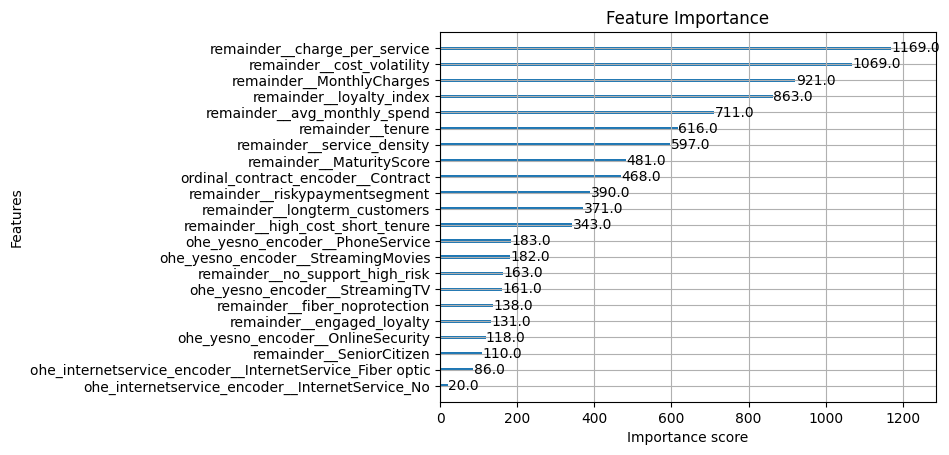

In [269]:
plt.figure(figsize=(8,6))
sorted_idx = best_model.feature_importances_.argsort()
xgb.plot_importance(best_model, show_values=True)
plt.title("Feature Importance")
plt.show()

In [270]:
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = best_pipeline.predict(X_test)

EVALUATION REPORT
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1035
           1       0.62      0.67      0.64       374

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409

Macro F1 Score:    0.7518


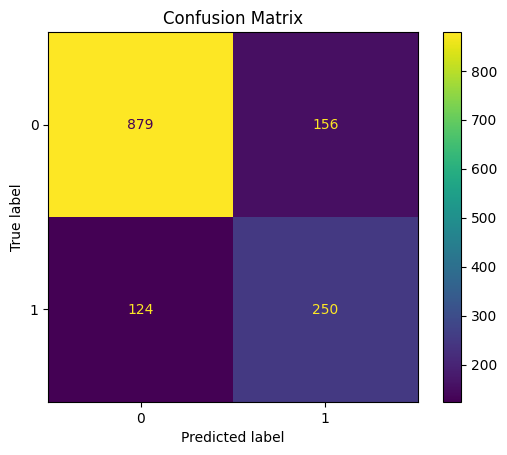

PR AUC Score: 0.668


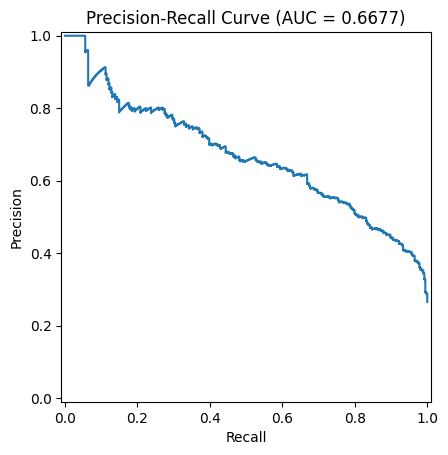

In [271]:
model_eval.evaluate_model(y_test, y_pred, y_proba)